In [5]:
# Importing libraries
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset

In [40]:
# Loading Data
df = load_dataset("lukebarousse/data_jobs")["train"].to_pandas()

In [41]:
# Data Cleaning
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

In [46]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


# Using Normal Array for Understanding

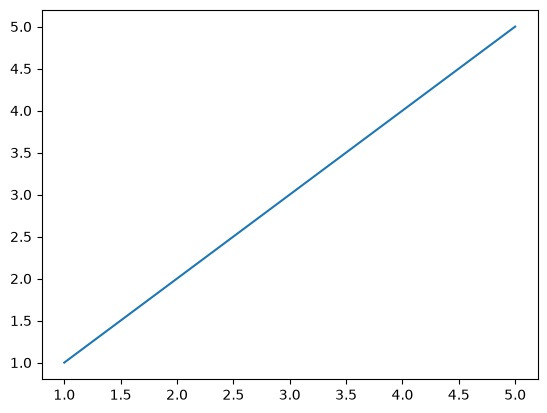

In [9]:
x = [1, 2, 3, 4, 5]
y = [1, 2, 3, 4, 5]

plt.plot(x,y)

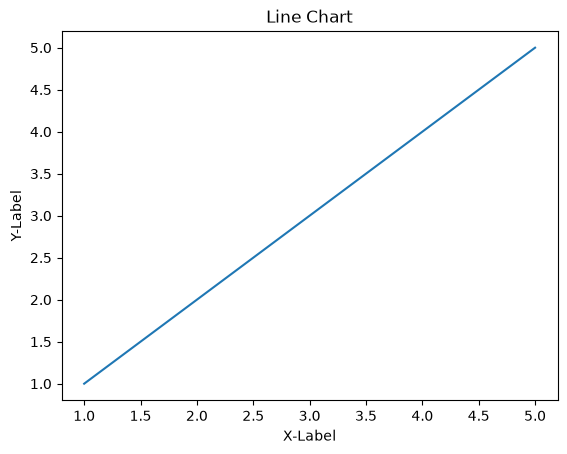

In [11]:
plt.title("Line Chart")
plt.xlabel("X-Label")
plt.ylabel("Y-Label")
plt.plot(x, y)
plt.show()      # Display the figure

# Using job DataFrame

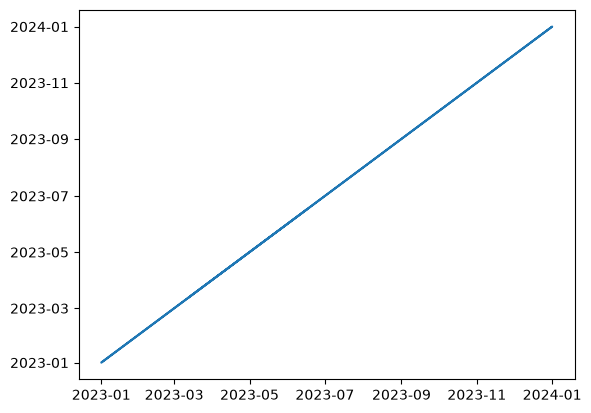

In [12]:
plt.plot(df["job_posted_date"], df["job_posted_date"])

In [48]:
job_count = df.groupby("job_title_short")["job_work_from_home"].count()     # Takes True and False both into consideration - ignores only null values

job_count

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
Name: job_work_from_home, dtype: int64

In [50]:
job_count = df.groupby("job_title_short")["job_title_short"].count()    

job_count

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
Name: job_title_short, dtype: int64

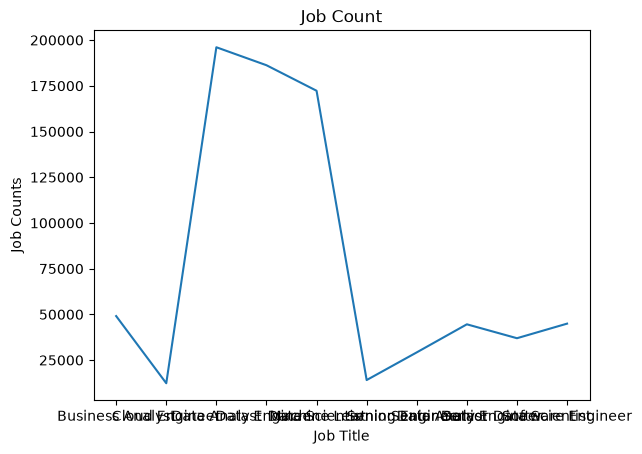

In [99]:
plt.title("Job Count")
plt.xlabel("Job Title")
plt.ylabel("Job Counts")
plt.plot(job_count.index, job_count)


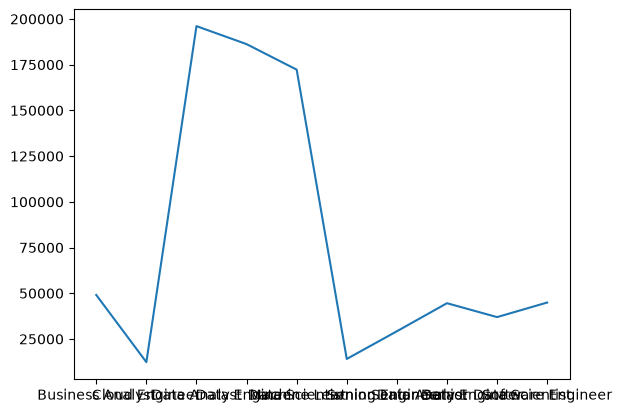

In [100]:
# or
plt.plot(job_count.index, job_count.values)

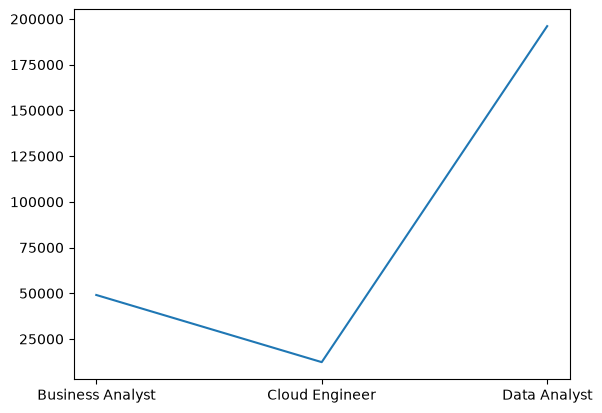

In [103]:
job_count_top_3 = df.groupby("job_title_short")["job_title_short"].count().head(3)
plt.plot(job_count_top_3.index, job_count_top_3)        # Now the overlapping of job title is gone

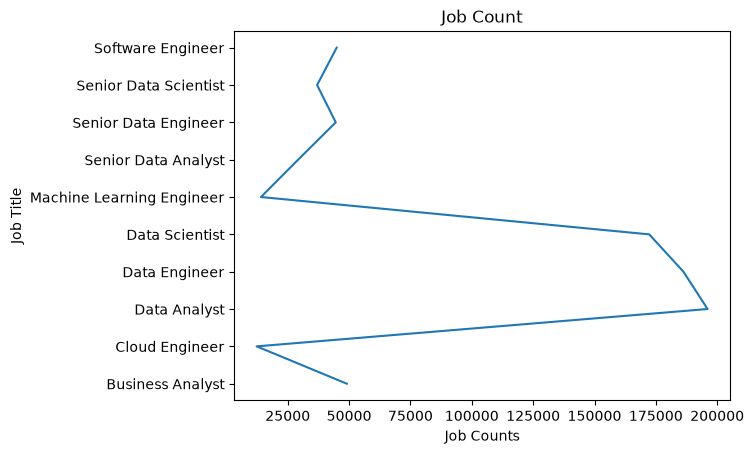

In [38]:
plt.title("Job Count")
plt.xlabel("Job Counts")
plt.ylabel("Job Title")
plt.plot(job_count, job_count.index)

In [76]:
job_date = df.groupby("job_posted_date")["job_posted_date"].count()

job_date

job_posted_date
2023-01-01 00:00:04    1
2023-01-01 00:00:07    1
2023-01-01 00:00:22    1
2023-01-01 00:00:24    1
2023-01-01 00:00:27    1
                      ..
2023-12-31 23:40:18    2
2023-12-31 23:40:22    2
2023-12-31 23:40:31    2
2023-12-31 23:40:32    1
2023-12-31 23:59:58    2
Name: job_posted_date, Length: 607192, dtype: int64

In [78]:
job_date = job_date.sort_index()            # 2023-01-01 00:00:04 - sorting this index

'\n2023-01-01 00:00:04    1\n2023-01-01 00:00:07    1\n2023-01-01 00:00:22    1\n2023-01-01 00:00:24    1\n2023-01-01 00:00:27    1\n'

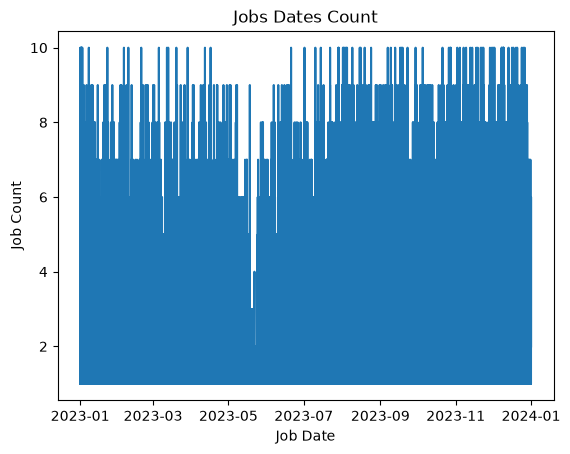

In [79]:
plt.title("Jobs Dates Count")
plt.xlabel("Job Date")
plt.ylabel("Job Count")
plt.plot(job_date.index, job_date)  

"""
2023-01-01 00:00:04    1
2023-01-01 00:00:07    1
2023-01-01 00:00:22    1
2023-01-01 00:00:24    1
2023-01-01 00:00:27    1
"""         # Observe the secs

In [42]:
df["job_posted_month"] = df["job_posted_date"].dt.month

In [85]:
job_date = df["job_posted_month"].value_counts()

job_date

job_posted_month
1     91822
8     75162
10    66611
2     64578
11    64450
3     64084
7     63777
4     62919
9     62359
6     61572
12    56303
5     52104
Name: count, dtype: int64

In [86]:
job_date = job_date.sort_index()

job_date

job_posted_month
1     91822
2     64578
3     64084
4     62919
5     52104
6     61572
7     63777
8     75162
9     62359
10    66611
11    64450
12    56303
Name: count, dtype: int64

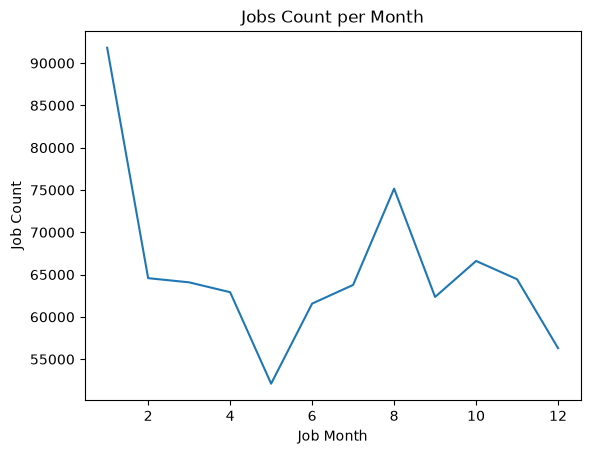

In [87]:
plt.title("Jobs Count per Month")
plt.xlabel("Job Month")
plt.ylabel("Job Count")
plt.plot(job_date.index, job_date)  

In [92]:
degree_not_mentioned = df[df["job_no_degree_mention"]]


degree_not_mentioned

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",7
10,Data Engineer,Erfahrene*r Data Engineer*in (m/w/d),"Basel, Switzerland",via LinkedIn,Full-time,False,Switzerland,2023-04-17 13:27:32,True,False,Switzerland,NaN,NaN,NaN,ROCKEN®,"['python', 'databricks', 'azure', 'spark']","{'cloud': ['databricks', 'azure'], 'libraries'...",4
13,Senior Data Engineer,Senior Data Engineer,"New York, NY",via LinkedIn,Full-time,False,"Texas, United States",2023-11-15 13:08:52,True,True,United States,NaN,NaN,NaN,Nayya,"['python', 'sql', 'go', 'ruby', 'ruby', 'javas...","{'cloud': ['aws'], 'other': ['terraform'], 'pr...",11
25,Senior Data Analyst,"Senior Officer, Data Analyst, GTO",Singapore,via BeBee Singapore,Full-time,False,Singapore,2023-06-23 13:56:10,True,False,Singapore,NaN,NaN,NaN,United Overseas Bank,['sql'],{'programming': ['sql']},6
26,Data Engineer,Data Engineer,United States,via LinkedIn,Full-time,False,Georgia,2023-09-15 13:56:18,True,False,United States,NaN,NaN,NaN,Infinite Computer Solutions,NaN,NaN,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785698,Data Engineer,"Data Engineer, Gerencia Business Intelligence","Las Condes, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-08-09 06:32:00,True,False,Chile,NaN,NaN,NaN,Falabella Retail,"['sql', 'python', 'gcp', 'aws', 'git']","{'cloud': ['gcp', 'aws'], 'other': ['git'], 'p...",8
785700,Data Engineer,Data Engineer Ssr/Sr,"Mexico City, CDMX, Mexico",via Trabajo.org,Full-time,False,Mexico,2023-01-12 06:19:55,True,False,Mexico,NaN,NaN,NaN,Tsoft,"['python', 'r', 'azure', 'aws', 'gcp', 'spark'...","{'cloud': ['azure', 'aws', 'gcp'], 'libraries'...",1
785701,Data Engineer,"Data Engineer, Gerencia Business Intelligence","Santiago, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-08-09 06:31:57,True,False,Chile,NaN,NaN,NaN,Falabella Retail,"['sql', 'python', 'gcp', 'aws', 'git']","{'cloud': ['gcp', 'aws'], 'other': ['git'], 'p...",8
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN,1


In [95]:
month_of_degree_not_mentioned_jobs = degree_not_mentioned.groupby("job_posted_month")["job_no_degree_mention"].count()


month_of_degree_not_mentioned_jobs

job_posted_month
1     27762
2     18985
3     18593
4     18706
5     14050
6     15678
7     19464
8     22626
9     21019
10    22954
11    21773
12    19166
Name: job_no_degree_mention, dtype: int64

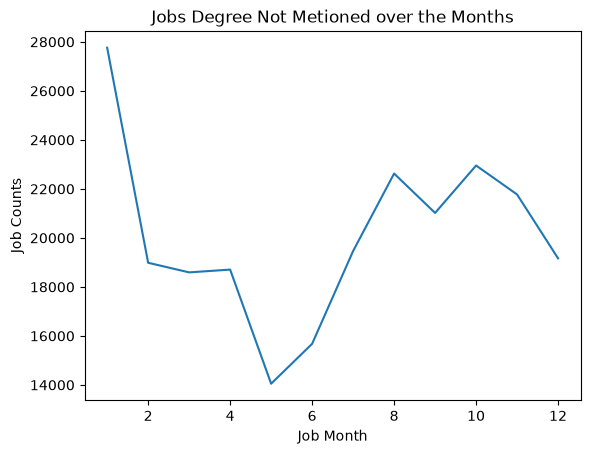

In [96]:
plt.title("Jobs Degree Not Metioned over the Months")
plt.xlabel("Job Month")
plt.ylabel("Job Counts")
plt.plot(month_of_degree_not_mentioned_jobs.index, month_of_degree_not_mentioned_jobs)

# BAR chart

In [105]:
job_ava_per_title = df["job_title_short"].value_counts()

job_ava_per_title

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

In [113]:
# or 

job_ava_per_title = df.groupby(["job_title_short"])["job_title_short"].count()

job_ava_per_title

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
Name: job_title_short, dtype: int64

<BarContainer object of 10 artists>

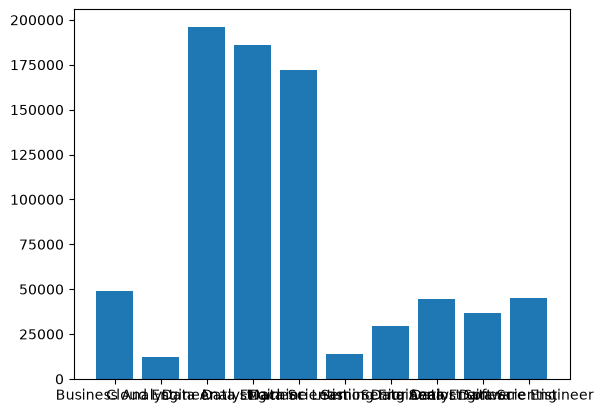

In [110]:
plt.bar(job_ava_per_title.index, job_ava_per_title)

<BarContainer object of 3 artists>

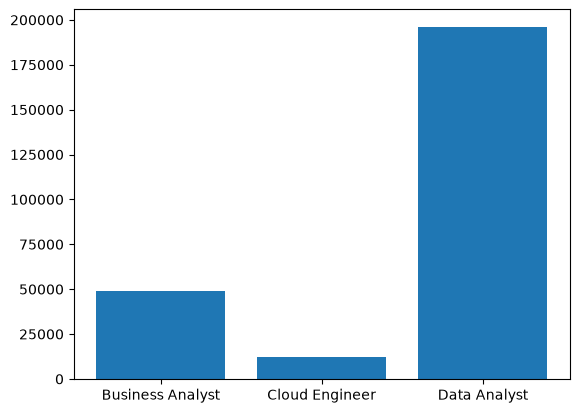

In [111]:
job_ava_per_title = job_ava_per_title.head(3)
plt.bar(job_ava_per_title.index, job_ava_per_title)

<BarContainer object of 10 artists>

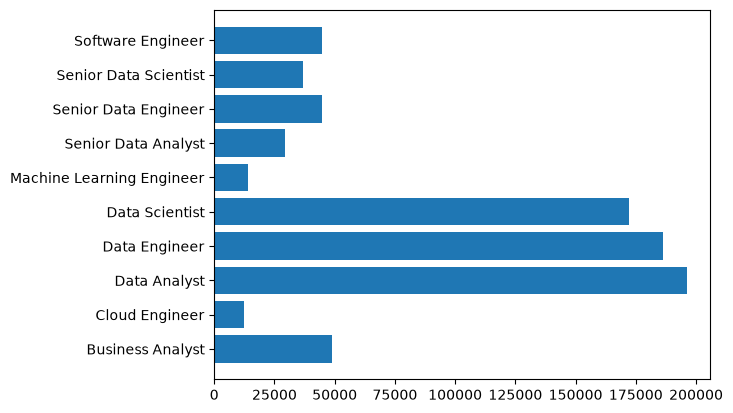

In [114]:
# Horizontal Bar Chart
plt.barh(job_ava_per_title.index, job_ava_per_title)

In [116]:
# sorting values
job_ava_per_title = df["job_title_short"].value_counts().sort_values()

<BarContainer object of 10 artists>

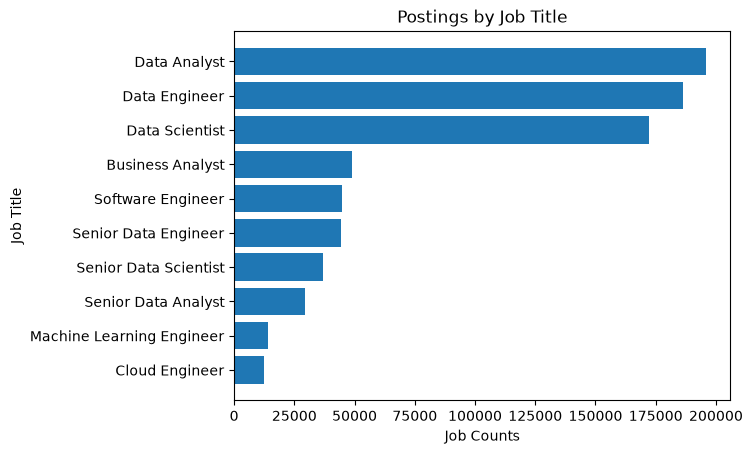

In [122]:
plt.title("Postings by Job Title")

plt.xlabel("Job Counts")

plt.ylabel("Job Title")

# Horizontal Bar Chart
plt.barh(job_ava_per_title.index, job_ava_per_title)

<BarContainer object of 10 artists>

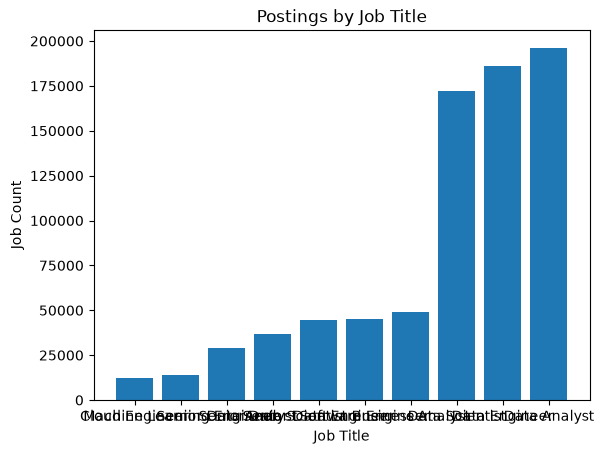

In [123]:
plt.title("Postings by Job Title")

plt.xlabel("Job Title")

plt.ylabel("Job Count")

# Bar Chart
plt.bar(job_ava_per_title.index, job_ava_per_title)

<BarContainer object of 10 artists>

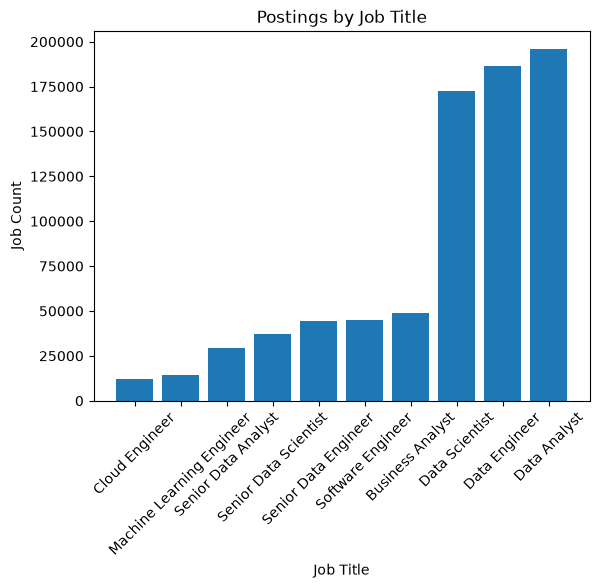

In [125]:
plt.title("Postings by Job Title")

plt.xlabel("Job Title")
plt.xticks(rotation=45)

plt.ylabel("Job Count")

# Bar Chart
plt.bar(job_ava_per_title.index, job_ava_per_title)         # As we can see the xlabes are not aligned properly

In [126]:
help(plt.xticks)

Help on function xticks in module matplotlib.pyplot:

xticks(
    ticks: ArrayLike | None = None,
    labels: Sequence[str] | None = None,
    *,
    minor: bool = False,
    **kwargs
) -> tuple[list[Tick] | np.ndarray, list[Text]]
    Get or set the current tick locations and labels of the x-axis.

    Pass no arguments to return the current values without modifying them.

    Parameters
    ----------
    ticks : array-like, optional
        The list of xtick locations.  Passing an empty list removes all xticks.
    labels : array-like, optional
        The labels to place at the given *ticks* locations.  This argument can
        only be passed if *ticks* is passed as well.
    minor : bool, default: False
        If ``False``, get/set the major ticks/labels; if ``True``, the minor
        ticks/labels.
    **kwargs
        `.Text` properties can be used to control the appearance of the labels.

        .. warning::

            This only sets the properties of the current ticks, wh

<BarContainer object of 10 artists>

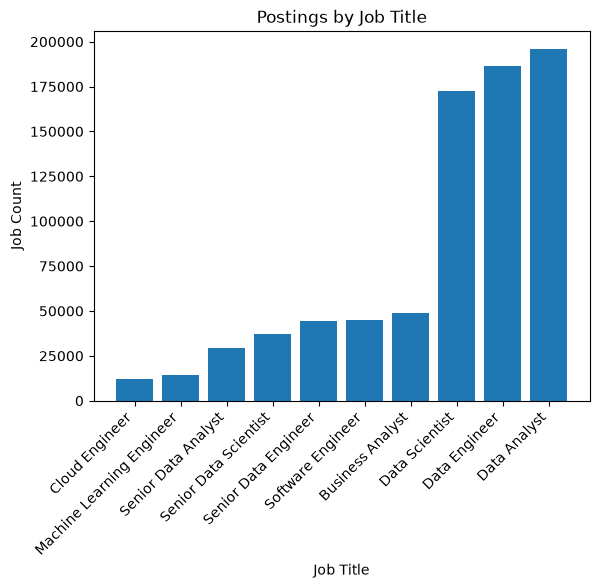

In [128]:
plt.title("Postings by Job Title")

plt.xlabel("Job Title")
plt.xticks(rotation=45, ha="right")     # Horizontal Alignment

plt.ylabel("Job Count")

# Bar Chart
plt.bar(job_ava_per_title.index, job_ava_per_title)

# Easy and Simple way to use the plots - In Pandas with DataFrame

In [131]:
job_ava_per_title

job_title_short
Cloud Engineer                12331
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Scientist         36957
Senior Data Engineer          44563
Software Engineer             44929
Business Analyst              49063
Data Scientist               172286
Data Engineer                186241
Data Analyst                 196075
Name: count, dtype: int64

<Axes: xlabel='job_title_short'>

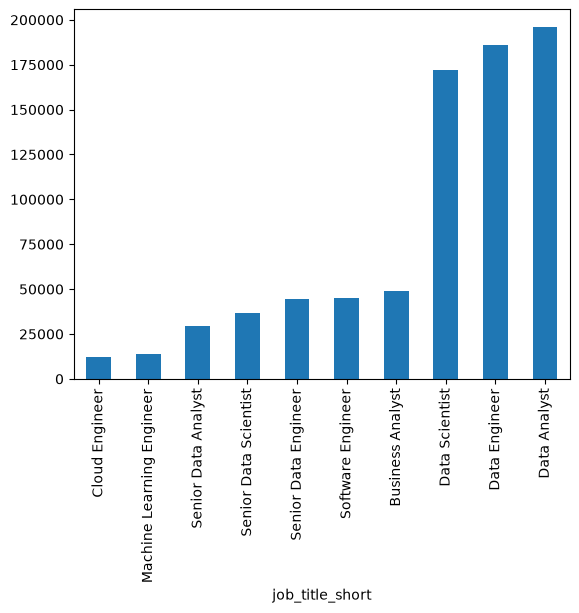

In [135]:
job_ava_per_title.plot(kind="bar")      # Remember that job_ava_per_title has to be a Series

In [10]:
df[["job_posted_date", "salary_year_avg"]]

,job_posted_date,salary_year_avg
0,2023-06-16 13:44:15,NaN
1,2023-01-14 13:18:07,NaN
2,2023-10-10 13:14:55,NaN
3,2023-07-04 13:01:41,NaN
4,2023-08-07 14:29:36,NaN
...,...,...
785736,2023-03-13 06:16:16,NaN
785737,2023-03-12 06:18:18,NaN
785738,2023-03-12 06:32:36,NaN
785739,2023-03-12 06:32:15,NaN


In [12]:
df[["job_posted_date", "salary_year_avg"]].dropna(subset="salary_year_avg")

,job_posted_date,salary_year_avg
28,2023-08-01 13:37:57,109500.0
77,2023-06-26 14:22:54,140000.0
92,2023-02-21 13:29:59,120000.0
100,2023-07-31 13:01:18,228222.0
109,2023-10-12 13:02:19,89000.0
...,...,...
785624,2023-08-31 06:02:16,139216.0
785641,2023-01-04 16:36:07,150000.0
785648,2023-04-12 06:02:51,221875.0
785682,2023-03-04 06:16:08,157500.0


In [14]:
df[["job_posted_date", "salary_year_avg"]].dropna(subset=["salary_year_avg"])       # not replaced

,job_posted_date,salary_year_avg
28,2023-08-01 13:37:57,109500.0
77,2023-06-26 14:22:54,140000.0
92,2023-02-21 13:29:59,120000.0
100,2023-07-31 13:01:18,228222.0
109,2023-10-12 13:02:19,89000.0
...,...,...
785624,2023-08-31 06:02:16,139216.0
785641,2023-01-04 16:36:07,150000.0
785648,2023-04-12 06:02:51,221875.0
785682,2023-03-04 06:16:08,157500.0


<Axes: xlabel='job_posted_date'>

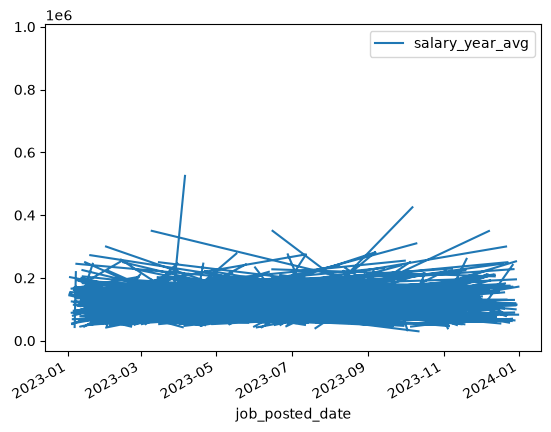

In [13]:
df.plot(kind="line", x="job_posted_date", y="salary_year_avg")

In [22]:
df = df[["job_posted_date", "salary_year_avg"]].dropna(subset=["salary_year_avg"])       # Assigned to new Variable

In [21]:
df

,job_posted_date,salary_year_avg
28,2023-08-01 13:37:57,109500.0
77,2023-06-26 14:22:54,140000.0
92,2023-02-21 13:29:59,120000.0
100,2023-07-31 13:01:18,228222.0
109,2023-10-12 13:02:19,89000.0
...,...,...
785624,2023-08-31 06:02:16,139216.0
785641,2023-01-04 16:36:07,150000.0
785648,2023-04-12 06:02:51,221875.0
785682,2023-03-04 06:16:08,157500.0


<Axes: xlabel='job_posted_date'>

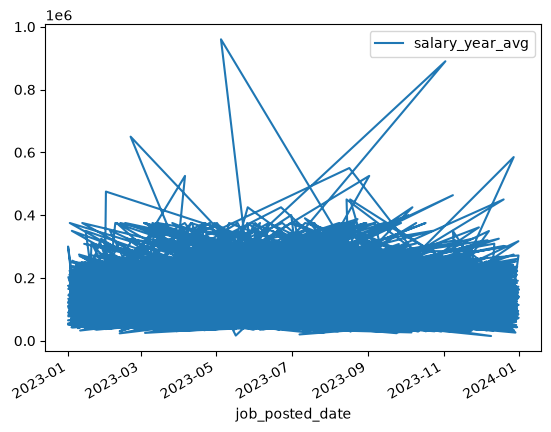

In [16]:
df.plot(kind="line", x="job_posted_date", y="salary_year_avg")

In [23]:
df = df[["job_posted_date", "salary_year_avg"]].dropna(subset=["salary_year_avg"]).sort_values(by="job_posted_date")       # Assigned to new Variable

<Axes: xlabel='job_posted_date'>

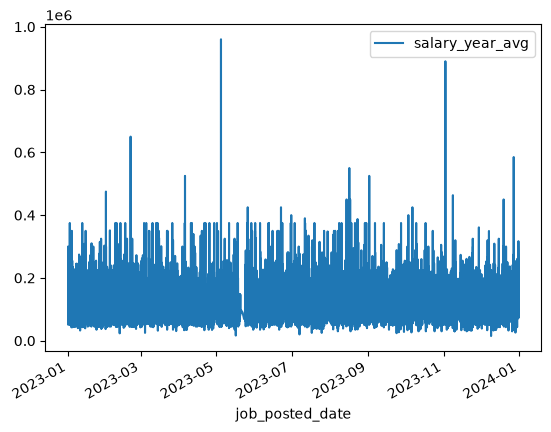

In [ ]:
df.plot(kind="line", x="job_posted_date", y="salary_year_avg")  

<Axes: xlabel='job_posted_month'>

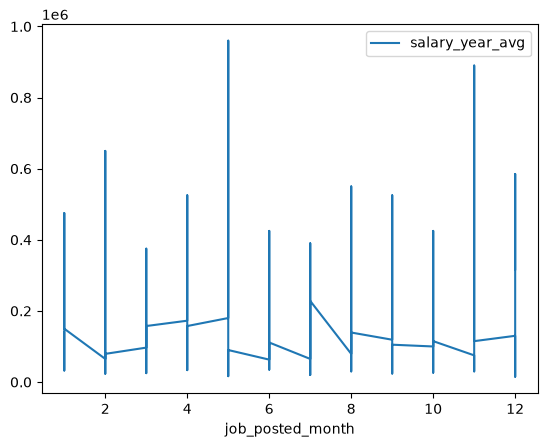

In [29]:
df = df[["job_posted_month", "salary_year_avg"]].dropna(subset=["salary_year_avg"]).sort_values(by="job_posted_month")

df.plot(kind="line", x="job_posted_month", y="salary_year_avg")

In [34]:
df

job_posted_month
1     2296
2     2010
3     2204
4     1876
5     1911
6     2331
7     2219
8     2095
9     1246
10    1310
11    1124
12    1381
Name: salary_year_avg, dtype: int64

In [38]:
df = df.groupby("job_posted_month")["salary_year_avg"].sum()

df

job_posted_month
1     2.824250e+08
2     2.470570e+08
3     2.709770e+08
4     2.286029e+08
5     2.363080e+08
6     2.897926e+08
7     2.739812e+08
8     2.635917e+08
9     1.560278e+08
10    1.632347e+08
11    1.346745e+08
12    1.659954e+08
Name: salary_year_avg, dtype: float64

<Axes: xlabel='job_posted_month'>

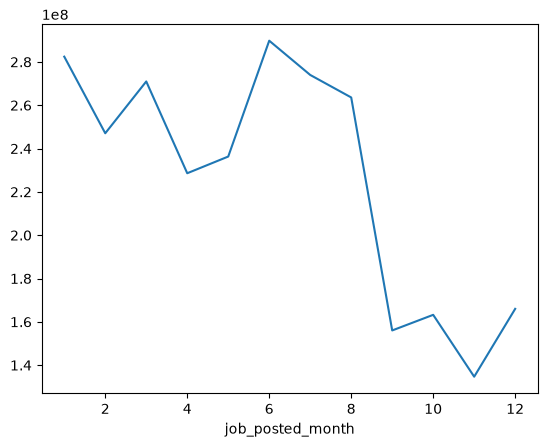

In [39]:
df.plot(kind="line", x="job_posted_month", y="salary_year_avg")

In [ ]:
job_posted_date = df["job_posted_date"].dt.date

job_posted_date

0         2023-06-16
1         2023-01-14
2         2023-10-10
3         2023-07-04
4         2023-08-07
             ...    
785736    2023-03-13
785737    2023-03-12
785738    2023-03-12
785739    2023-03-12
785740    2023-03-13
Name: job_posted_date, Length: 785741, dtype: object

In [45]:
df["job_posted_date"] = job_posted_date

df.sort_values(by="job_posted_date", inplace=True)

df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
461362,Data Scientist,Turing Hiring Near Me – Remote Data Scientist ...,"Palo Alto, CA",via Jobs Picks,Full-time,False,"California, United States",2023-01-01,False,False,United States,NaN,NaN,NaN,Turing,"['python', 'tensorflow', 'keras', 'pandas', 'n...","{'libraries': ['tensorflow', 'keras', 'pandas'...",1
274144,Data Scientist,STAGE - Assistant(e) Data Scientist – Quantum ...,"Montrouge, France",via BeBee,Internship,False,France,2023-01-01,False,False,France,NaN,NaN,NaN,Crédit Agricole S.A.,NaN,NaN,1
364349,Data Analyst,Functional analyst Adobe Analytics,"Madrid, Spain",via Recruit.net,Full-time,False,Spain,2023-01-01,False,False,Spain,NaN,NaN,NaN,Krell Consulting & Training,"['html', 'css', 'javascript', 'sql']","{'programming': ['html', 'css', 'javascript', ...",1
364347,Senior Data Engineer,Senior Data Engineer (Innovation Insurer),Hong Kong,via Jobs In Hong Kong,Full-time,False,Hong Kong,2023-01-01,False,False,Hong Kong,NaN,NaN,NaN,MatchTalent Limited,"['sql', 'mongodb', 'mongodb', 'r', 'python', '...","{'analyst_tools': ['alteryx', 'tableau', 'qlik...",1
346928,Cloud Engineer,"Data Center Storage with Avamar/Sacramento, CA...","Sacramento, CA",via LinkedIn,Contractor,False,"California, United States",2023-01-01,True,False,United States,NaN,NaN,NaN,Suncap Technology,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61924,Machine Learning Engineer,Senior/Staff MLOps Engineer,"Denver, CO",via BeBee,Full-time,False,Sudan,2023-12-31,False,True,Sudan,NaN,NaN,NaN,EvenUp,"['elasticsearch', 'bigquery']","{'cloud': ['bigquery'], 'databases': ['elastic...",12
646083,Data Scientist,DATA SCIENTIST regio Utrecht – PHARMO Institut...,"Nieuwegein, Netherlands",via Utrecht.work,Full-time,False,Netherlands,2023-12-31,False,False,Netherlands,NaN,NaN,NaN,Nationale Vacaturebank,NaN,NaN,12
411096,Data Scientist,Data Scientist Specialist,Argentina,via LinkedIn,Full-time,False,Argentina,2023-12-31,False,False,Argentina,NaN,NaN,NaN,ICBC Argentina,"['python', 'sql', 'nosql', 'gcp', 'aws', 'azur...","{'analyst_tools': ['power bi'], 'cloud': ['gcp...",12
702239,Data Analyst,Technical Data Analyst,"Manila, Metro Manila, Philippines",via Ai-Jobs.net,Full-time,False,Philippines,2023-12-31,False,False,Philippines,year,89204.0,NaN,SupportNinja,"['windows', 'excel', 'jira']","{'analyst_tools': ['excel'], 'async': ['jira']...",12


In [49]:
salary_sum_per_date = df.groupby("job_posted_date")["salary_year_avg"].sum()

salary_sum_per_date

job_posted_date
2023-01-01    2.676680e+06
2023-01-02    1.030135e+07
2023-01-03    7.215866e+06
2023-01-04    1.430880e+07
2023-01-05    1.248659e+07
                  ...     
2023-12-27    6.270608e+06
2023-12-28    4.714973e+06
2023-12-29    7.238739e+06
2023-12-30    3.946428e+06
2023-12-31    2.855498e+06
Name: salary_year_avg, Length: 365, dtype: float64

<Axes: xlabel='job_posted_date'>

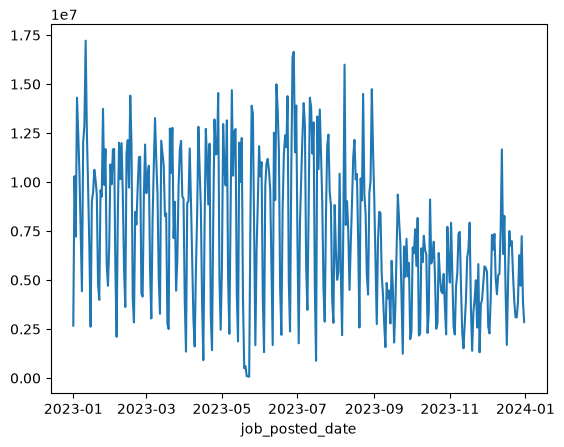

In [53]:
salary_sum_per_date.plot(kind="line", x="job_posted_date", y="salary_year_avg")

In [54]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
461362,Data Scientist,Turing Hiring Near Me – Remote Data Scientist ...,"Palo Alto, CA",via Jobs Picks,Full-time,False,"California, United States",2023-01-01,False,False,United States,NaN,NaN,NaN,Turing,"['python', 'tensorflow', 'keras', 'pandas', 'n...","{'libraries': ['tensorflow', 'keras', 'pandas'...",1
274144,Data Scientist,STAGE - Assistant(e) Data Scientist – Quantum ...,"Montrouge, France",via BeBee,Internship,False,France,2023-01-01,False,False,France,NaN,NaN,NaN,Crédit Agricole S.A.,NaN,NaN,1
364349,Data Analyst,Functional analyst Adobe Analytics,"Madrid, Spain",via Recruit.net,Full-time,False,Spain,2023-01-01,False,False,Spain,NaN,NaN,NaN,Krell Consulting & Training,"['html', 'css', 'javascript', 'sql']","{'programming': ['html', 'css', 'javascript', ...",1
364347,Senior Data Engineer,Senior Data Engineer (Innovation Insurer),Hong Kong,via Jobs In Hong Kong,Full-time,False,Hong Kong,2023-01-01,False,False,Hong Kong,NaN,NaN,NaN,MatchTalent Limited,"['sql', 'mongodb', 'mongodb', 'r', 'python', '...","{'analyst_tools': ['alteryx', 'tableau', 'qlik...",1
346928,Cloud Engineer,"Data Center Storage with Avamar/Sacramento, CA...","Sacramento, CA",via LinkedIn,Contractor,False,"California, United States",2023-01-01,True,False,United States,NaN,NaN,NaN,Suncap Technology,NaN,NaN,1


In [63]:
"""
    Why are we using "median" instead of "mean": 
    It's Because we may contain the Data like this-
    [1, 2, 3, 4, 100] - so since now 100 is the extreme value it will also increase the mean value 
    Which is not accurate and clear for analysing 
    "So, we used median here" - Typically shows middle salary
    Whereas mean considers all the salaries
    Disadvantage - it ignores extreme value
    


    Mean is best when we have values like this - Ex: [1, 2, 3] because here the data is consistent and doesn't consist the extreme values
    Ans as we can see:
    Mean = 2
    Median = 2
    The Data is balanced around the center.
"""

median_salary = df.groupby("job_title_short")["salary_year_avg"].median()  

median_salary

job_title_short
Business Analyst              85000.0
Cloud Engineer                90000.0
Data Analyst                  90000.0
Data Engineer                125000.0
Data Scientist               127500.0
Machine Learning Engineer    106415.0
Senior Data Analyst          111175.0
Senior Data Engineer         147500.0
Senior Data Scientist        155500.0
Software Engineer             99150.0
Name: salary_year_avg, dtype: float64

In [73]:
median_salary = df.groupby("job_title_short")["salary_year_avg"].median().sort_values()  

median_salary

job_title_short
Business Analyst              85000.0
Cloud Engineer                90000.0
Data Analyst                  90000.0
Software Engineer             99150.0
Machine Learning Engineer    106415.0
Senior Data Analyst          111175.0
Data Engineer                125000.0
Data Scientist               127500.0
Senior Data Engineer         147500.0
Senior Data Scientist        155500.0
Name: salary_year_avg, dtype: float64

In [ ]:
# Now compare this cell values with median_values output

mean_salary = df.groupby("job_title_short")["salary_year_avg"].mean().sort_values()

mean_salary     # As we can see here that only "Senior Data Scientist and Senior Data Engineer's" value matches all the others don't 


job_title_short
Business Analyst              91082.612833
Data Analyst                  93841.907854
Cloud Engineer               111268.453846
Software Engineer            113393.760054
Senior Data Analyst          113911.363665
Machine Learning Engineer    126774.315972
Data Engineer                130125.604250
Data Scientist               135988.837171
Senior Data Engineer         145840.611624
Senior Data Scientist        154206.292996
Name: salary_year_avg, dtype: float64

<Axes: ylabel='job_title_short'>

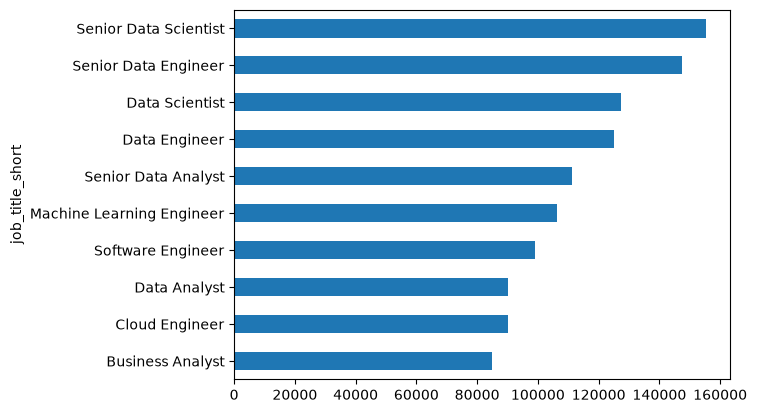

In [74]:
median_salary.plot(kind="barh")

<BarContainer object of 10 artists>

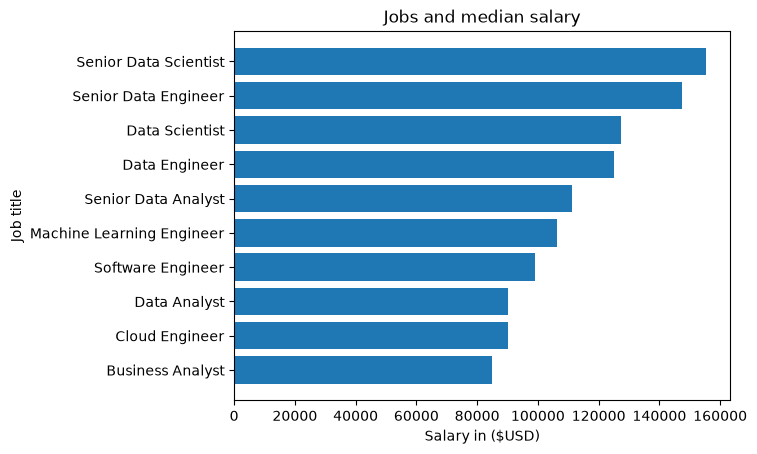

In [75]:
plt.title("Jobs and median salary")
plt.xlabel("Salary in ($USD)")
plt.ylabel("Job title")
plt.barh(median_salary.index, median_salary)


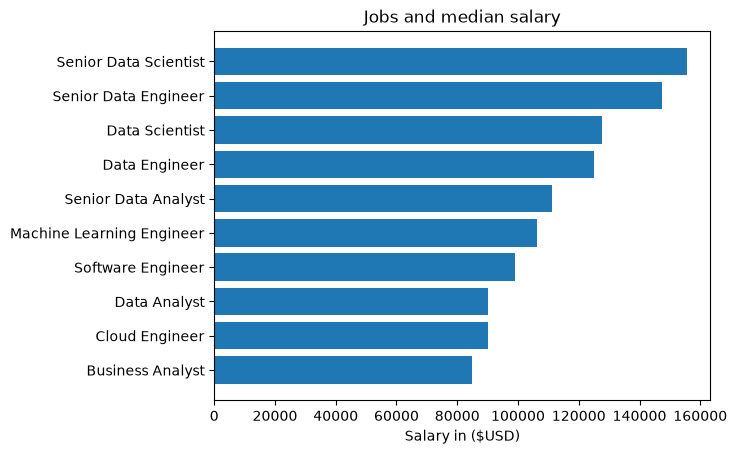

In [76]:
# Best Practice 

plt.title("Jobs and median salary")
plt.xlabel("Salary in ($USD)")
plt.barh(median_salary.index, median_salary)
plt.show()